# Question
 Recall the pattern generation and the Delayed Column Generation (DCG) algorithm for the 1D Cutting
Stock Problem (CSP). Instead of one, there are two types of stock. The following details are provided in the file **items.xlsx** :

• The length of the different stocks is provided in stocks sheet.

• The length and corresponding demand of the different items (to be cut from the stocks) are provided
in items sheet.


(a) Generate all ‘good’ patterns - that yield a trim-loss of less than or equal to 2, and use just these
patterns to solve the CSP (LP relaxation). If you get a fractional solution, round it up.
The code must print:
1. total number of patterns generated
2. total number of stocks of each type used in the optimal solution
3. computational time taken in seconds for pattern generation and solving the model

In [335]:
import time

start_time = time.perf_counter()

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

np.random.seed(0)

In [336]:
# def duplicate_remover(list_):
#     # Convert each sublist to a tuple and store in a set to remove duplicates
#     unique_tuples = set(map(tuple, list_))

#     # Convert the unique tuples back to a list of lists
#     unique_list = list(map(list, unique_tuples))

#     return unique_list

In [337]:
# Opening an excel file and reading each sheet
with pd.ExcelFile("items.xlsx") as xls:
    items_df = pd.read_excel(xls,"items")
    stocks_df = pd.read_excel(xls,"stocks", dtype=float)

items_df

,Item Length,Demand
0,1.5,20
1,2.0,15
2,3.5,13
3,4.5,8
4,5.5,9
5,6.5,5
6,7.0,6
7,8.5,7
8,9.0,4
9,10.5,6


In [338]:
item_lengths = np.array(items_df["Item Length"])
stock_lengths = np.array(stocks_df, dtype='g').flatten()

min_item_length = np.min(item_lengths)

# pattern list of good patterns of each stock type
patterns = []

# # loop on different stocks
# for i in range(len(stock_lengths)):
#     stock_length = stock_lengths[i]
#     # good pattern list
#     good_pattern = []
#     for _ in range(100000):
#         # loop to make patterns
#         pattern = []
#         k = int(stock_length/min_item_length)
#         for j in range(k):
#             # if sum of item lengths + new item length is less than or equal to stock length 
#             item_length = np.random.choice(item_lengths)
#             if sum(pattern) + item_length<= stock_lengths[i]:
#                 pattern.append(item_length)
#         # Filtering good pattern
#         if stock_lengths[i] - sum(pattern) < 2:
#             good_pattern.append(sorted(pattern))
#     # good pattern as a set along with sorted pattern to remove duplicate entries
    
#     # append the good pattern as a list in patterns for each stock type
#     patterns.append(duplicate_remover(good_pattern))


min_item_length = item_lengths.min()
patterns = []

for stock_length in stock_lengths:
    n_patterns = 1000000
    max_items = int(stock_length / min_item_length)

    random_items = np.random.choice(item_lengths, size=(n_patterns, max_items))
    cumsum = np.cumsum(random_items, axis=1)

    valid_counts = (cumsum <= stock_length).sum(axis=1)
    valid = valid_counts > 0

    last_idx = valid_counts[valid] - 1
    used = cumsum[valid, last_idx]
    waste = stock_length - used

    good = waste < 2
    good_rows = np.where(valid)[0][good]
    good_counts = valid_counts[valid][good]


    mask = np.arange(max_items) < good_counts[:, None]
    cut_patterns = random_items[good_rows] * mask

    cut_patterns = np.sort(cut_patterns, axis=1)
    cut_patterns = cut_patterns[:, cut_patterns.any(axis=0)]

    unique_patterns = np.unique(cut_patterns, axis=0)

    patterns.append(unique_patterns.tolist())



In [339]:

pd.options.display.max_rows = 150

In [340]:
# making a dataframe so as to visualize patterns with column names
patterns_df = pd.DataFrame(patterns).T
patterns_df.columns=[f"Good patterns for the stock length: {i}" for i in stock_lengths]
patterns_df

,Good patterns for the stock length: 10.0,Good patterns for the stock length: 12.0,Good patterns for the stock length: 15.0
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 8.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 13.5]"
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 9.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 9.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 13.5]"
2,"[0.0, 0.0, 0.0, 0.0, 1.5, 7.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 10.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.5, 10.5]"
3,"[0.0, 0.0, 0.0, 0.0, 1.5, 8.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 8.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.5, 9.0]"
4,"[0.0, 0.0, 0.0, 0.0, 2.0, 6.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 9.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.5, 10.5]"
5,"[0.0, 0.0, 0.0, 0.0, 2.0, 7.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 3.5, 7.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.5, 8.5]"
6,"[0.0, 0.0, 0.0, 0.0, 3.5, 5.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 3.5, 8.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.5, 9.0]"
7,"[0.0, 0.0, 0.0, 0.0, 3.5, 6.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 4.5, 6.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.5, 7.0]"
8,"[0.0, 0.0, 0.0, 0.0, 4.5, 4.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 4.5, 7.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.5, 8.5]"
9,"[0.0, 0.0, 0.0, 0.0, 4.5, 5.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 5.5, 5.5]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 7.0]"


In [341]:

print(patterns_df.count())
total_patterns = sum([len(i) for i in patterns])
print(f'Total number of good patterns are {total_patterns}')

Good patterns for the stock length: 10.0     37
Good patterns for the stock length: 12.0     65
Good patterns for the stock length: 15.0    134
dtype: int64
Total number of good patterns are 236


In [342]:
patterns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 3 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Good patterns for the stock length: 10.0  37 non-null     object
 1   Good patterns for the stock length: 12.0  65 non-null     object
 2   Good patterns for the stock length: 15.0  134 non-null    object
dtypes: object(3)
memory usage: 3.3+ KB


In [343]:
listA = [[patterns[i][j] for i in range(len(patterns)) for j in range(len(patterns[i]))]]
df = pd.DataFrame(listA).T
df.columns=["Pattern"]

stock_corresponding_to_pattern = []
for j in range(len(patterns)):
    for i in range(len(patterns[j])):
        stock_corresponding_to_pattern.append(stock_lengths[j])

df["Length of stock used"] = stock_corresponding_to_pattern
df

,Pattern,Length of stock used
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 8.5]",10.0
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 9.0]",10.0
2,"[0.0, 0.0, 0.0, 0.0, 1.5, 7.0]",10.0
3,"[0.0, 0.0, 0.0, 0.0, 1.5, 8.5]",10.0
4,"[0.0, 0.0, 0.0, 0.0, 2.0, 6.5]",10.0
...,...,...
231,"[0.0, 1.5, 1.5, 1.5, 2.0, 2.0, 2.0, 4.5]",15.0
232,"[0.0, 1.5, 1.5, 2.0, 2.0, 2.0, 2.0, 3.5]",15.0
233,"[0.0, 1.5, 2.0, 2.0, 2.0, 2.0, 2.0, 3.5]",15.0
234,"[1.5, 1.5, 1.5, 1.5, 1.5, 2.0, 2.0, 3.5]",15.0


In [344]:
count_list = []
for i in df["Pattern"]:
    freq = []
    for j in item_lengths:
        num = i.count(j)
        freq.append(num)
    count_list.append(freq)

A = np.matrix(count_list)
pd.DataFrame(A, columns=item_lengths).join(df["Pattern"])

,1.5,2.0,3.5,4.5,5.5,6.5,7.0,8.5,9.0,10.5,13.5,Pattern
0,0,0,0,0,0,0,0,1,0,0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 8.5]"
1,0,0,0,0,0,0,0,0,1,0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 9.0]"
2,1,0,0,0,0,0,1,0,0,0,0,"[0.0, 0.0, 0.0, 0.0, 1.5, 7.0]"
3,1,0,0,0,0,0,0,1,0,0,0,"[0.0, 0.0, 0.0, 0.0, 1.5, 8.5]"
4,0,1,0,0,0,1,0,0,0,0,0,"[0.0, 0.0, 0.0, 0.0, 2.0, 6.5]"
...,...,...,...,...,...,...,...,...,...,...,...,...
231,3,3,0,1,0,0,0,0,0,0,0,"[0.0, 1.5, 1.5, 1.5, 2.0, 2.0, 2.0, 4.5]"
232,2,4,1,0,0,0,0,0,0,0,0,"[0.0, 1.5, 1.5, 2.0, 2.0, 2.0, 2.0, 3.5]"
233,1,5,1,0,0,0,0,0,0,0,0,"[0.0, 1.5, 2.0, 2.0, 2.0, 2.0, 2.0, 3.5]"
234,5,2,1,0,0,0,0,0,0,0,0,"[1.5, 1.5, 1.5, 1.5, 1.5, 2.0, 2.0, 3.5]"


In [345]:
S = df["Length of stock used"]
S

0      10.0
1      10.0
2      10.0
3      10.0
4      10.0
       ... 
231    15.0
232    15.0
233    15.0
234    15.0
235    15.0
Name: Length of stock used, Length: 236, dtype: float64

In [346]:
D = items_df["Demand"]
D

0     20
1     15
2     13
3      8
4      9
5      5
6      6
7      7
8      4
9      6
10     5
Name: Demand, dtype: int64

- $s_i$ is the stock length, $\forall i \in N=\{1,2,...,n\}$, $\in \mathbb{Z}^+$
  
- $p_{ij}$ is the good pattern for stock length $i$, $j \in M_i=\{1,2,...,m_i\}, \forall  i \in N$

- $l_k$ is the length of item $k$, $\forall k \in E=\{1,2,...,e\}$,  $\in \mathbb{Z}^+$

- $d_k$ is the demand of item $k$, $\forall k \in E$,  $\in \mathbb{Z}^+$

- $x_{p_{ij}}$ is number of times pattern $p_{ij}$ is used, $\in \mathbb{Z}^+$

- $a_{{l_k}{p_{ij}}}$ is the number of items of length $l_k$ used in pattern $p_{ij}$, $\in \mathbb{Z}^+$

**Decision variable is $x_{p_{ij}}$**

Then, the formulation is the following:
$$\begin{align}
\min \quad & \sum_{p_{ij}\in P} x_{p_{ij}}s_i \\
\text{s.t.} \quad & \sum_{p_{ij}\in P} a_{{l_k}{p_{ij}}} x_{p_{ij}} \geq d_k  && \forall k \in E \\
\end{align}$$

In [347]:
import gurobipy as gp 
from gurobipy import GRB 

In [348]:
# Make a model
m = gp.Model('CuttingStock')

In [349]:
# A vetctor containing decision variables with (shape total_patterns,1)
x = m.addMVar(lb=0,vtype=GRB.INTEGER, shape=total_patterns, name="x")

In [350]:
# Objective
m.setObjective(S.to_numpy()@x, GRB.MINIMIZE)

In [351]:
# Add constraint
c = m.addConstr(A.T@x >= D.to_numpy(), name="c")

In [352]:
# Solve the model
m.optimize()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) 5 120U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 11 rows, 236 columns and 601 nonzeros (Min)
Model fingerprint: 0xa22b5f49
Model has 236 linear objective coefficients
Variable types: 0 continuous, 236 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [1e+01, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 2e+01]
Found heuristic solution: objective 945.0000000
Presolve removed 1 rows and 51 columns
Presolve time: 0.00s
Presolved: 10 rows, 185 columns, 479 nonzeros
Variable types: 0 continuous, 185 integer (0 binary)

Root relaxation: objective 4.915000e+02, 18 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent

In [353]:
if m.status == GRB.OPTIMAL:
    print(f"Optimal objective function value: {m.ObjVal:g}")
    print(f"Decision variables x: {x.X.astype(int)}")
    print(f'Total solve time: {m.Runtime:.4f} seconds')
else:
    print("No Optimal Solution found.")

Optimal objective function value: 492
Decision variables x: [0 0 0 7 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 6 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 5 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Total solve time: 0.1130 seconds


In [354]:
df["Number of times used"] = x.X.astype(int)

In [355]:
result_df = df[df["Number of times used"]>0]
result_df

,Pattern,Length of stock used,Number of times used
3,"[0.0, 0.0, 0.0, 0.0, 1.5, 8.5]",10.0,7
9,"[0.0, 0.0, 0.0, 0.0, 4.5, 5.5]",10.0,1
12,"[0.0, 0.0, 0.0, 1.5, 1.5, 7.0]",10.0,1
39,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 10.5]",12.0,6
47,"[0.0, 0.0, 0.0, 0.0, 0.0, 5.5, 6.5]",12.0,5
103,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 13.5]",15.0,5
134,"[0.0, 0.0, 0.0, 0.0, 0.0, 3.5, 4.5, 7.0]",15.0,5
135,"[0.0, 0.0, 0.0, 0.0, 0.0, 3.5, 5.5, 5.5]",15.0,1
162,"[0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 9.0]",15.0,4
172,"[0.0, 0.0, 0.0, 0.0, 3.5, 3.5, 3.5, 4.5]",15.0,2


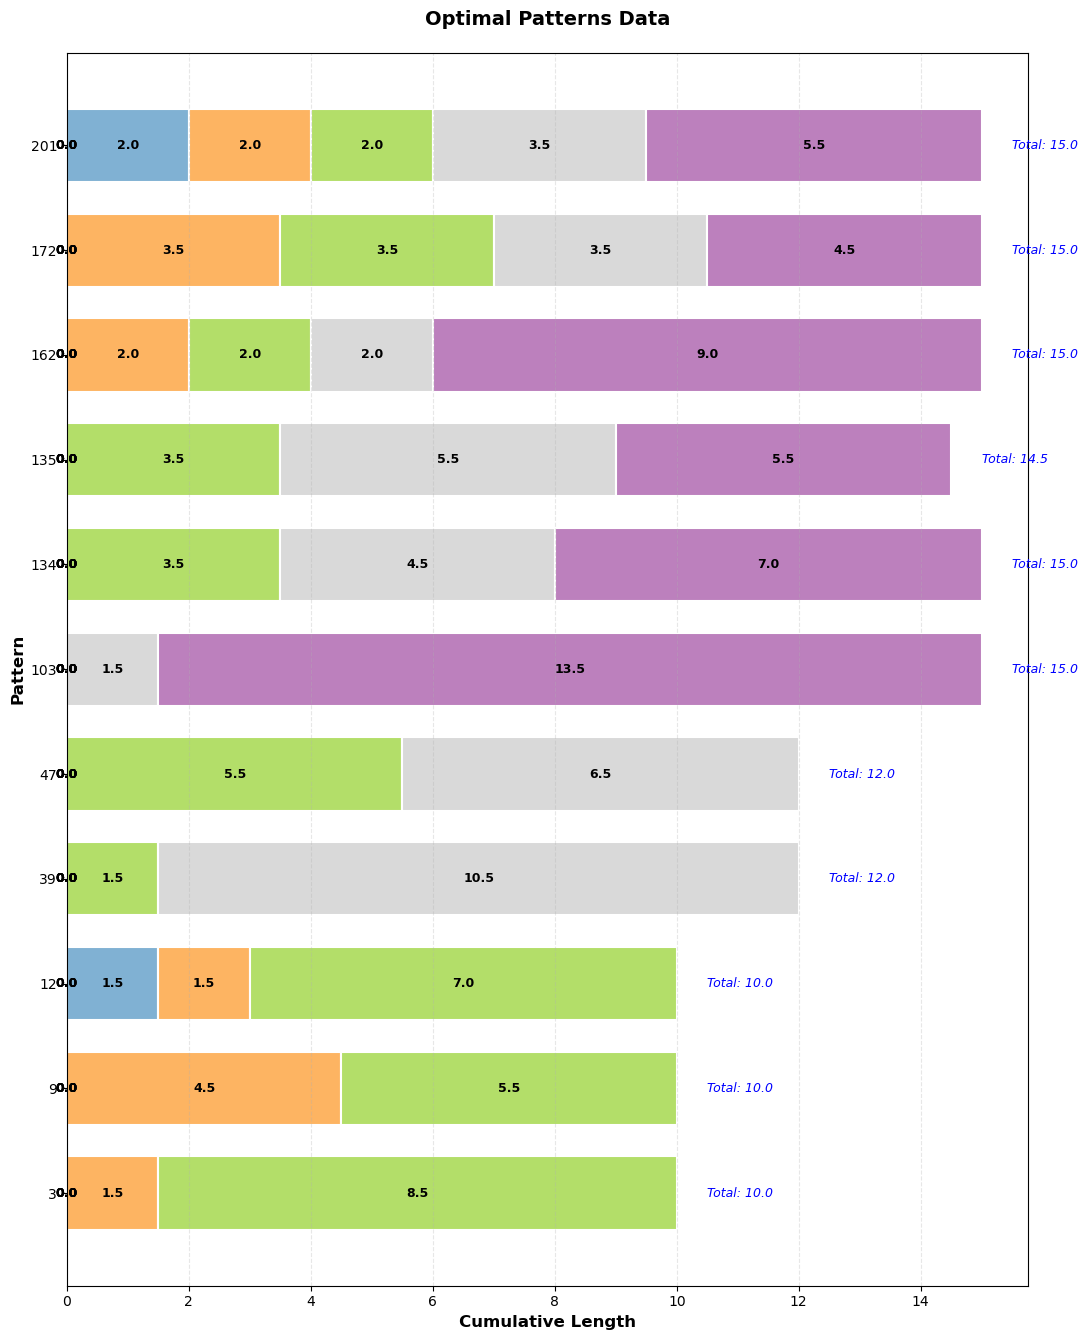

In [356]:
# Create figure
fig, ax = plt.subplots(figsize=(result_df["Pattern"].count(), max(item_lengths)))

# Define colors for segments (using a colormap)
colors = plt.cm.Set3(np.linspace(0, 1, 10))

# Plot each pattern as a horizontal stacked bar
y_positions = range(len(result_df))
labels = result_df.index.tolist()

for i, (index, row) in enumerate(result_df.iterrows()):
    values = row['Pattern']  # Get the list of values from the Pattern column
    left = 0
    for j, value in enumerate(values):
        ax.barh(i, value, left=left, height=0.7, 
                color=colors[j % len(colors)], 
                edgecolor='white', linewidth=1.5)
        # Add value labels on each segment
        ax.text(left + value/2, i, f'{value}', 
                ha='center', va='center', fontsize=9, fontweight='bold')
        left += value

# Customize the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel('Cumulative Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Pattern', fontsize=12, fontweight='bold')
ax.set_title('Optimal Patterns Data', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add total value at the end of each bar
for i, (index, row) in enumerate(result_df.iterrows()):
    total = sum(row['Pattern'])
    ax.text(total + 0.5, i, f'Total: {total}', 
            va='center', fontsize=9, style='italic', color='blue')

plt.tight_layout()
plt.savefig('pattern_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [357]:
for i in stock_lengths:
    num_stock_used =  result_df.loc[result_df["Length of stock used"] == i,"Number of times used"].sum()
    print(f"Number of stock of length {i} used: {num_stock_used}")

Number of stock of length 10.0 used: 9
Number of stock of length 12.0 used: 11
Number of stock of length 15.0 used: 18


In [358]:
end_time = time.perf_counter()
runtime = end_time - start_time

print(f"The script took {runtime:.4f} seconds to complete.")

The script took 4.7718 seconds to complete.
